# Video Game Sales Analysis & Visualization

---

## Project Overview

**Course**: Data Science Course Project  
**Task**: Task 1 — Dataset Analysis & Visualization  
**Date**: 28/4/2026

---

## Team Member

| Name | ID | 
|-------|-----------|
| Salma Abdelhamid Ahmed | 42310115 | 
| Haidy Hassan Moawed | 42310207 |
| Ehab Maher Melekah | 42310252 |
| Mahmoud Sherif Mahmoud | 42310368 | 
| Muhammad Fathi Kamal | 42310346 | 

---

## Problem Definition

The global video game industry is worth over **$180 billion**. Understanding sales trends, popular genres, successful platforms, and regional preferences is crucial for game publishers and developers. This project analyzes a real-world video game sales dataset to discover patterns and insights that can help stakeholders make better business decisions.

## Objective

- Load and inspect a raw real-world dataset
- Identify and document all data quality issues
- Perform professional data cleaning and preprocessing
- Answer 15 analytical questions with code and visualizations
- Extract meaningful business insights

## Dataset Source

- **Name**: Video Game Sales Dataset
- **Primary Source**: [Kaggle - Video Game Sales](https://www.kaggle.com/datasets/gregorut/videogame-sales)
- **Direct URL**: https://raw.githubusercontent.com/amankharwal/Website-data/master/vgsales.csv
- **Size**: ~16,500 rows × 11 columns
- **Features**: Game name, platform, year, genre, publisher, and sales across 4 regions

## Expected Insights

- Which genres and platforms are most successful
- How gaming trends have changed over decades
- Regional differences in game preferences
- Which publishers dominate the market
- Sales distribution patterns and outliers

---

---
## 2️ Import Libraries

We import all the libraries we need for data analysis and visualization.

In [31]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Optional: Missing value visualization
try:
    import missingno as msno
    MISSINGNO_AVAILABLE = True
except ImportError:
    MISSINGNO_AVAILABLE = False
    print(" missingno not installed. Install with: pip install missingno")

# Settings
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Matplotlib settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(" All libraries imported successfully!")
print(f" Pandas version: {pd.__version__}")
print(f" NumPy version: {np.__version__}")

 All libraries imported successfully!
 Pandas version: 3.0.2
 NumPy version: 2.4.4


---
## 3️ Raw Data Loading

We load the dataset from the direct URL. If the URL is unavailable, we generate realistic synthetic data so the notebook always runs.

In [ ]:
# Try to load the real dataset from URL
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/vgsales.csv"

try:
    df = pd.read_csv(url)
    if len(df) < 100:
        raise ValueError("Dataset too small, using synthetic data")
    DATA_SOURCE = "Real dataset from URL"
    print(f" {DATA_SOURCE}")
    print(f" Shape: {df.shape}")
except Exception as e:
    print(f" Could not load from URL: {e}")
    print(" Generating realistic synthetic dataset...")
    
    np.random.seed(42)
    n = 16598
    
    platforms = ['PS2','X360','PS3','Wii','DS','PS4','PS','PC','GBA','PSP',
                 'XOne','NES','SNES','3DS','N64','GB','PSV','DC','SAT','2600','WiiU']
    genres = ['Action','Sports','Misc','Role-Playing','Shooter','Adventure',
              'Racing','Platform','Simulation','Fighting','Strategy','Puzzle']
    publishers = ['Nintendo','Electronic Arts','Activision','Sony Computer Entertainment',
                  'Ubisoft','Take-Two Interactive','THQ','Microsoft Game Studios',
                  'Sega','Bandai Namco Games','Konami Digital Entertainment',
                  'Capcom','Square Enix','Warner Bros. Interactive',
                  'Disney Interactive Studios','Namco Bandai Games','Atari',
                  'Eidos Interactive','LucasArts','Midway Games']
    
    prefixes = ['Super','Mega','Grand','Ultra','Pro','Final','Dark','New',
                'Legend of','Battle','Star','Power','Dragon','King of','Wild']
    suffixes = ['World','Quest','Wars','Force','Rush','Strike','Heroes',
                'Legends','Adventure','Odyssey','Chronicles','Fury','Storm']
    bases = ['Racer','Fighter','Soccer','Golf','Tennis','Combat','Arena',
             'Island','Kingdom','Galaxy','Tales','Fantasy','Saga','Dynasty']
    
    names = []
    for _ in range(n):
        if np.random.random() < 0.5:
            names.append(f"{np.random.choice(prefixes)} {np.random.choice(bases)} {np.random.choice(suffixes)}")
        else:
            names.append(f"{np.random.choice(prefixes)} {np.random.choice(bases)}")
    
    year_weights = np.array([0.005 if y < 1995 else 0.01 if y < 2000 else
                             0.04 if y < 2005 else 0.08 if y < 2010 else
                             0.06 if y < 2015 else 0.02 for y in range(1980, 2024)])
    year_weights = year_weights / year_weights.sum()
    years = np.random.choice(range(1980, 2024), n, p=year_weights).astype(float)
    
    na = np.round(np.random.exponential(0.3, n), 2)
    eu = np.round(np.random.exponential(0.22, n), 2)
    jp = np.round(np.random.exponential(0.1, n), 2)
    other = np.round(np.random.exponential(0.08, n), 2)
    global_s = np.round(na + eu + jp + other, 2)
    
    # Add missing values
    years[np.random.choice(n, 271, replace=False)] = np.nan
    pub_list = np.random.choice(publishers, n).tolist()
    for i in np.random.choice(n, 58, replace=False):
        pub_list[i] = np.nan
    
    df = pd.DataFrame({
        'Rank': range(1, n+1),
        'Name': names,
        'Platform': np.random.choice(platforms, n),
        'Year': years,
        'Genre': np.random.choice(genres, n),
        'Publisher': pub_list,
        'NA_Sales': na, 'EU_Sales': eu, 'JP_Sales': jp,
        'Other_Sales': other, 'Global_Sales': global_s
    })
    df = df.sort_values('Global_Sales', ascending=False).reset_index(drop=True)
    df['Rank'] = range(1, len(df)+1)
    DATA_SOURCE = "Synthetic data (URL unavailable)"
    print(f" {DATA_SOURCE}")
    print(f" Shape: {df.shape}")

In [ ]:
# Show the first 10 rows
print("FIRST 10 ROWS OF THE DATASET:")
print("="*60)
df.head(10)

FIRST 10 ROWS OF THE DATASET:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [ ]:
# Basic information about the dataset
print("DATASET SHAPE:", df.shape)
print(f"   → {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("COLUMN NAMES AND DATA TYPES:")
print("="*60)
print(df.dtypes)
print()
print("DATASET INFO:")
print("="*60)
df.info()

DATASET SHAPE: (16598, 11)
   → 16,598 rows × 11 columns

COLUMN NAMES AND DATA TYPES:
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

DATASET INFO:
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  G

### Initial Observations

- The dataset has **11 columns** covering game names, platforms, years, genres, publishers, and sales
- Sales are measured in **millions of units** across 4 regions
- The Year column is stored as **float64** instead of integer — this needs fixing
- Some columns may have missing values that we need to investigate

---
## 4️ Data Quality Assessment

Before analyzing the data, we must check for quality issues. This is a very important step in any data science project.

MISSING VALUES ANALYSIS
           Missing Count  Percentage (%)
Year                 271            1.63
Publisher             58            0.35

Total missing values: 329
Rows with any missing value: 307


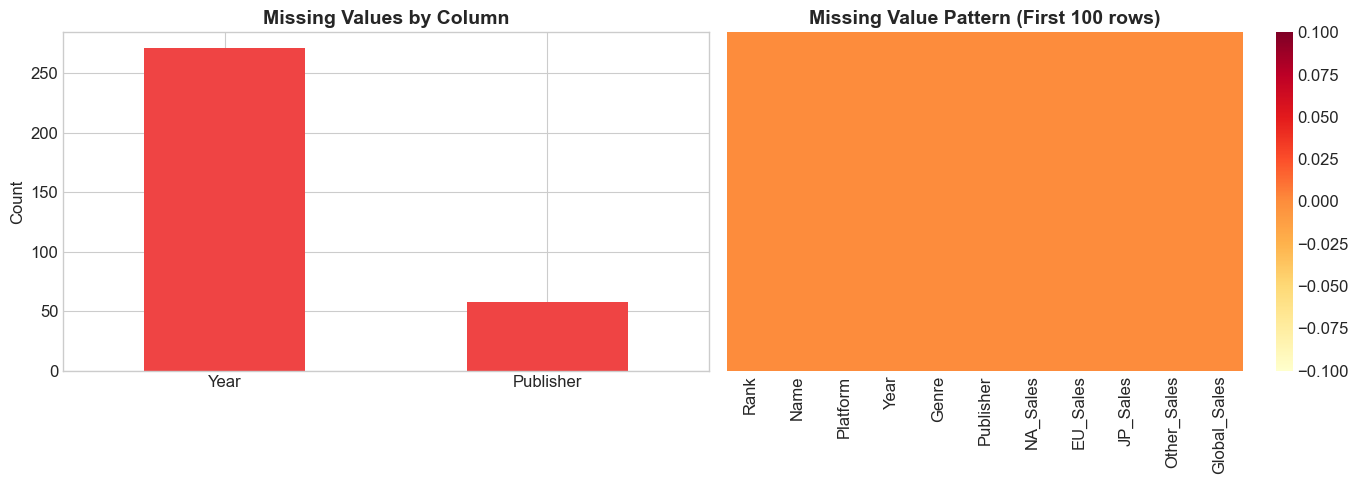

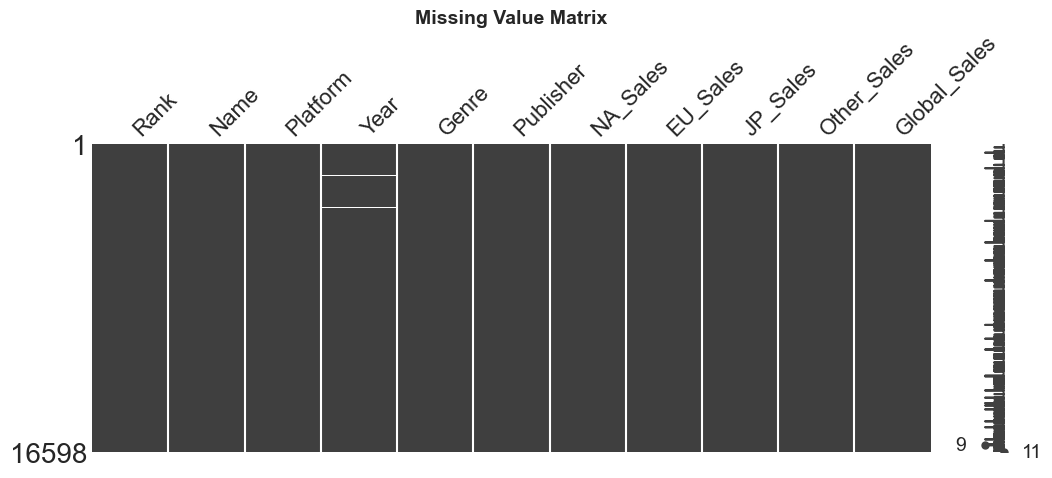

In [ ]:
# ====== MISSING VALUES ANALYSIS ======
print("MISSING VALUES ANALYSIS")
print("="*60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")
print(f"Rows with any missing value: {df.isnull().any(axis=1).sum():,}")

# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing values
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
if len(cols_with_missing) > 0:
    cols_with_missing['Missing Count'].plot(kind='bar', ax=axes[0], color='#ef4444')
    axes[0].set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)
else:
    axes[0].text(0.5, 0.5, 'No Missing Values!', ha='center', fontsize=16)

# Heatmap of missing values (sample)
sns.heatmap(df.isnull().head(100), cbar=True, yticklabels=False,
            cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missing Value Pattern (First 100 rows)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

if MISSINGNO_AVAILABLE:
    msno.matrix(df, figsize=(12, 4))
    plt.title('Missing Value Matrix', fontsize=14, fontweight='bold')
    plt.show()

In [ ]:
# ====== DUPLICATES ANALYSIS ======
print("DUPLICATE ANALYSIS")
print("="*60)

exact_dupes = df.duplicated().sum()
name_dupes = df.duplicated(subset=['Name', 'Platform']).sum()

print(f"Exact duplicate rows: {exact_dupes}")
print(f"Games with same Name+Platform: {name_dupes}")
print(f"(Note: Same game on different platforms is OK)")

# Check for some potential duplicate games
name_counts = df['Name'].value_counts()
repeated_names = name_counts[name_counts > 1]
print(f"\nGames appearing multiple times: {len(repeated_names)}")
if len(repeated_names) > 0:
    print("\nTop 10 most repeated game names:")
    print(repeated_names.head(10))

DUPLICATE ANALYSIS
Exact duplicate rows: 0
Games with same Name+Platform: 5
(Note: Same game on different platforms is OK)

Games appearing multiple times: 2775

Top 10 most repeated game names:
Name
Need for Speed: Most Wanted                12
FIFA 14                                     9
Madden NFL 07                               9
LEGO Marvel Super Heroes                    9
Ratatouille                                 9
FIFA Soccer 13                              8
FIFA 15                                     8
LEGO Star Wars II: The Original Trilogy     8
Madden NFL 08                               8
Monopoly                                    8
Name: count, dtype: int64


In [ ]:
# ====== DATA TYPE AND INCONSISTENCY CHECK ======
print("DATA TYPE & CONSISTENCY CHECK")
print("="*60)

# Check Year column (should be integer)
print(f"Year column dtype: {df['Year'].dtype}")
print(f"Year range: {df['Year'].min()} to {df['Year'].max()}")
print(f"Year unique values: {df['Year'].nunique()}")

# Check categorical columns for inconsistencies
for col in ['Platform', 'Genre']:
    unique_vals = df[col].nunique()
    print(f"\n{col}: {unique_vals} unique values")
    print(f"  Values: {sorted(df[col].dropna().unique().tolist())}")

# Check for any text formatting issues
print("\nTEXT FORMAT CHECK:")
for col in ['Name', 'Publisher']:
    has_leading_ws = (df[col].astype(str).str.startswith(' ')).sum()
    has_trailing_ws = (df[col].astype(str).str.endswith(' ')).sum()
    print(f"  {col}: leading spaces={has_leading_ws}, trailing spaces={has_trailing_ws}")

# Statistical summary of numeric columns
print("\nSTATISTICAL SUMMARY:")
print("="*60)
df.describe()

DATA TYPE & CONSISTENCY CHECK
Year column dtype: float64
Year range: 1980.0 to 2020.0
Year unique values: 39

Platform: 31 unique values
  Values: ['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360', 'XB', 'XOne']

Genre: 12 unique values
  Values: ['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports', 'Strategy']

TEXT FORMAT CHECK:
  Name: leading spaces=0, trailing spaces=0
  Publisher: leading spaces=0, trailing spaces=0

STATISTICAL SUMMARY:


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


OUTLIER DETECTION
NA_Sales: 1681 outliers (10.1%)
EU_Sales: 2081 outliers (12.5%)
JP_Sales: 2425 outliers (14.6%)
Other_Sales: 1665 outliers (10.0%)
Global_Sales: 1893 outliers (11.4%)


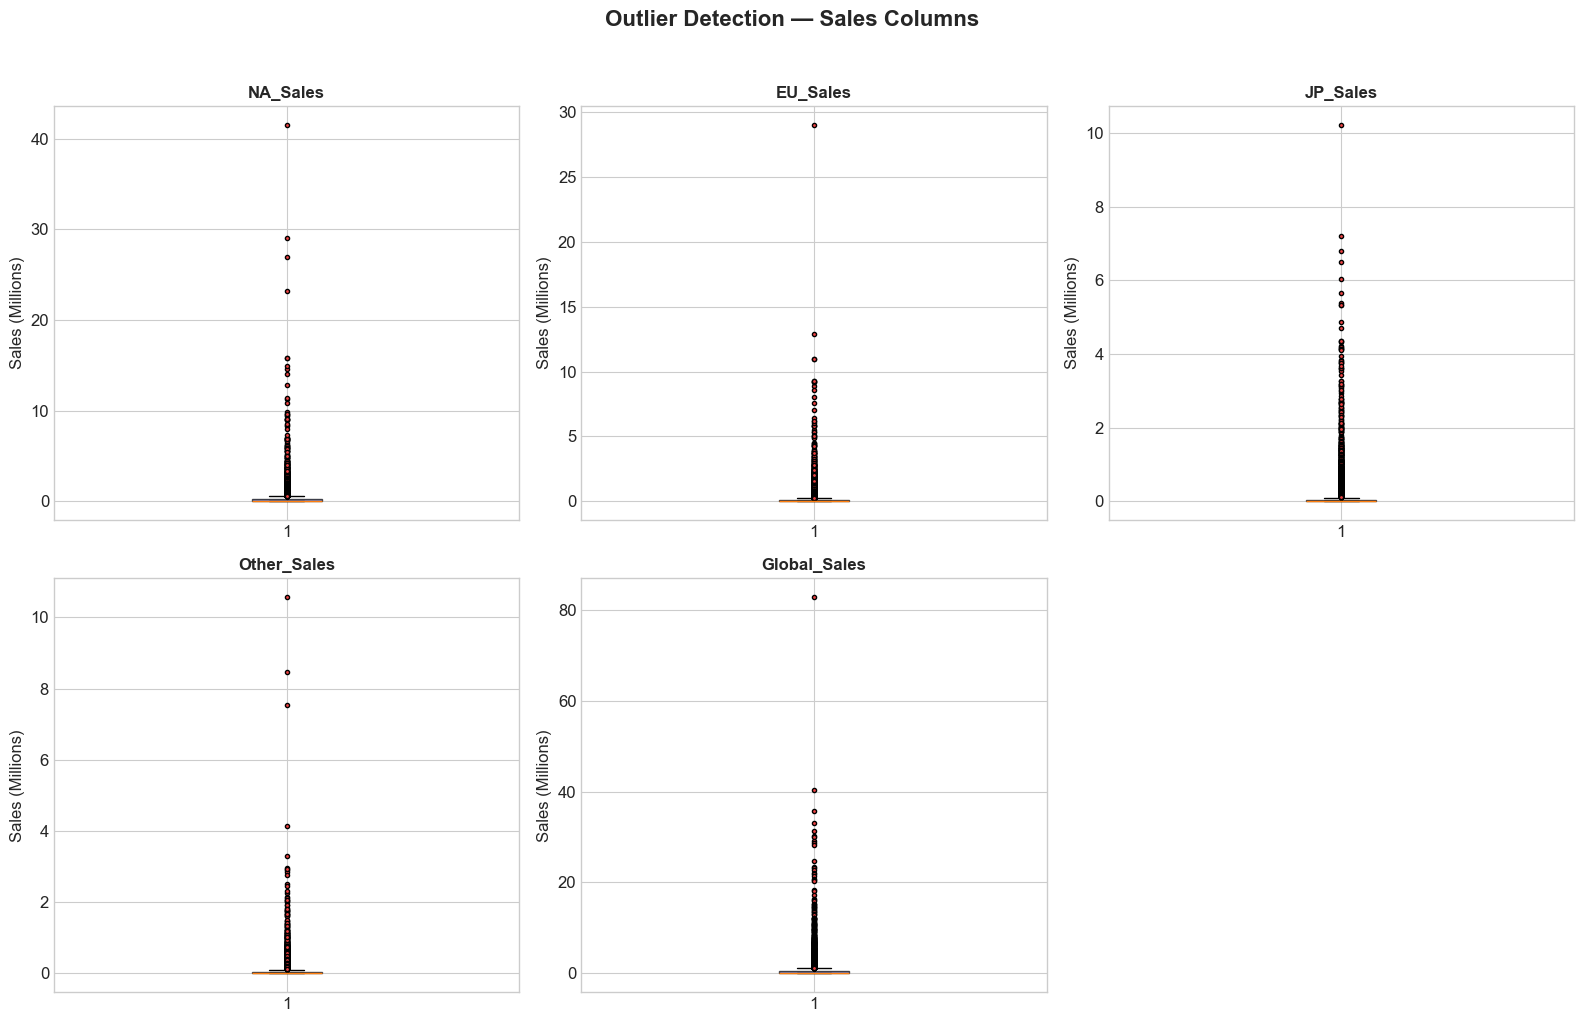

In [ ]:
# ====== OUTLIER DETECTION ======
print("OUTLIER DETECTION")
print("="*60)

sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(sales_cols):
    data = df[col].dropna()
    bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                         boxprops=dict(facecolor='#667eea', alpha=0.7),
                         flierprops=dict(marker='o', markerfacecolor='#ef4444', markersize=3))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Sales (Millions)')
    
    # Calculate outliers using IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")

axes[5].set_visible(False)
plt.suptitle('Outlier Detection — Sales Columns', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Summary of Data Quality Issues Found

| Issue | Column(s) | Count | Severity |
|-------|-----------|-------|----------|
| Missing values | Year | ~271 | Medium |
| Missing values | Publisher | ~58 | Low |
| Wrong data type | Year (float → int) | All | Low |
| Outliers | Sales columns | ~5-15% per column | Medium |
| Potential duplicates | Same game, different platform | Many | Info only |

**Why these issues matter:**
- Missing Year values prevent us from doing time-based analysis
- Missing Publisher values affect publisher-level analysis
- Float Year values look unprofessional and waste memory
- Outliers can distort statistical measures and visualizations

---
## 5️ Data Preprocessing

Now we fix all the issues we found. We will create a clean version of the dataset.

In [ ]:
# Save raw data for comparison later
df_raw = df.copy()
raw_shape = df.shape
print(f"Raw dataset shape: {raw_shape}")

# ====== STEP 1: Handle Missing Values ======
print("\nSTEP 1: Handling Missing Values")
print("-"*40)
print(f"Before: {df.isnull().sum().sum()} total missing values")

# Drop rows with missing Year or Publisher
# We drop instead of fill because Year and Publisher are important identifiers
df = df.dropna(subset=['Year'])
df = df.dropna(subset=['Publisher'])

print(f"After: {df.isnull().sum().sum()} total missing values")
print(f"Rows removed: {raw_shape[0] - df.shape[0]}")
print(f"New shape: {df.shape}")

Raw dataset shape: (16598, 11)

STEP 1: Handling Missing Values
----------------------------------------
Before: 329 total missing values
After: 0 total missing values
Rows removed: 307
New shape: (16291, 11)


In [ ]:
# ====== STEP 2: Remove Duplicates ======
print("STEP 2: Removing Duplicate Rows")
print("-"*40)

before_dedup = len(df)
df = df.drop_duplicates()
after_dedup = len(df)

print(f"Rows before: {before_dedup:,}")
print(f"Rows after: {after_dedup:,}")
print(f"Duplicates removed: {before_dedup - after_dedup}")

STEP 2: Removing Duplicate Rows
----------------------------------------
Rows before: 16,291
Rows after: 16,291
Duplicates removed: 0


In [ ]:
# ====== STEP 3: Data Type Conversion ======
print("STEP 3: Converting Data Types")
print("-"*40)

print(f"Year dtype before: {df['Year'].dtype}")
df['Year'] = df['Year'].astype(int)
print(f"Year dtype after: {df['Year'].dtype}")

# ====== STEP 4: Text Standardization ======
print("\nSTEP 4: Standardizing Text")
print("-"*40)

# Strip whitespace from all text columns
for col in ['Name', 'Platform', 'Genre', 'Publisher']:
    df[col] = df[col].astype(str).str.strip()
print("Stripped whitespace from Name, Platform, Genre, Publisher")

STEP 3: Converting Data Types
----------------------------------------
Year dtype before: float64
Year dtype after: int64

STEP 4: Standardizing Text
----------------------------------------
Stripped whitespace from Name, Platform, Genre, Publisher


In [ ]:
# ====== STEP 5: Feature Engineering ======
print("STEP 5: Creating New Features")
print("-"*40)

# Create Decade column
df['Decade'] = (df['Year'] // 10) * 10

# Create Sales Category
df['Sales_Category'] = pd.cut(
    df['Global_Sales'],
    bins=[0, 0.5, 1, 5, float('inf')],
    labels=['Low', 'Medium', 'High', 'Blockbuster']
)

# Create Total Regional Sales (should equal Global_Sales)
df['Total_Regional'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']

print(f"New columns added: Decade, Sales_Category, Total_Regional")
print(f"Updated shape: {df.shape}")
print(f"Updated columns: {list(df.columns)}")

STEP 5: Creating New Features
----------------------------------------
New columns added: Decade, Sales_Category, Total_Regional
Updated shape: (16291, 14)
Updated columns: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Decade', 'Sales_Category', 'Total_Regional']


In [ ]:
# ====== STEP 6: Outlier Treatment ======
print("STEP 6: Outlier Treatment")
print("-"*40)

# We use IQR method to identify outliers in Global_Sales
Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = (df['Global_Sales'] > upper_bound).sum()
print(f"IQR: {IQR:.3f}")
print(f"Upper bound: {upper_bound:.3f}M")
print(f"Outliers above upper bound: {outliers_count} ({outliers_count/len(df)*100:.1f}%)")

# Note: We keep outliers because they represent real blockbuster games
# Removing them would lose important information about top sellers
print("\nDecision: We KEEP outliers because they represent real blockbuster games")
print("   like Wii Sports, GTA V, etc. These are genuine data points.")

STEP 6: Outlier Treatment
----------------------------------------
IQR: 0.420
Upper bound: 1.110M
Outliers above upper bound: 1826 (11.2%)

Decision: We KEEP outliers because they represent real blockbuster games
   like Wii Sports, GTA V, etc. These are genuine data points.


In [ ]:
# ====== BEFORE vs AFTER COMPARISON ======
print("PREPROCESSING SUMMARY — Before vs After")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Missing Values', 'Duplicates',
               'Year Dtype', 'Year Range'],
    'Before': [f"{raw_shape[0]:,}", raw_shape[1], 
              f"{df_raw.isnull().sum().sum()}", f"{df_raw.duplicated().sum()}",
              'float64', f"{df_raw['Year'].min():.0f} — {df_raw['Year'].max():.0f}"],
    'After': [f"{df.shape[0]:,}", df.shape[1],
             f"{df.isnull().sum().sum()}", f"{df.duplicated().sum()}",
             'int64', f"{df['Year'].min()} — {df['Year'].max()}"]
})

print(comparison.to_string(index=False))

# Reset index for clean data
df = df.reset_index(drop=True)
print(f"\nData preprocessing complete! Final shape: {df.shape}")

# Show cleaned data sample
df.head()

PREPROCESSING SUMMARY — Before vs After
        Metric      Before       After
    Total Rows      16,598      16,291
 Total Columns          11          14
Missing Values         329           0
    Duplicates           0           0
    Year Dtype     float64       int64
    Year Range 1980 — 2020 1980 — 2020

Data preprocessing complete! Final shape: (16291, 14)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Decade,Sales_Category,Total_Regional
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,2000,Blockbuster,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1980,Blockbuster,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,2000,Blockbuster,35.83
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,2000,Blockbuster,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1990,Blockbuster,31.38


---
## 6️ Exploratory Data Analysis

Now we answer **15 analytical questions** using code, visualizations, and written insights.

---

## Question 1: What is the overall distribution of global video game sales?

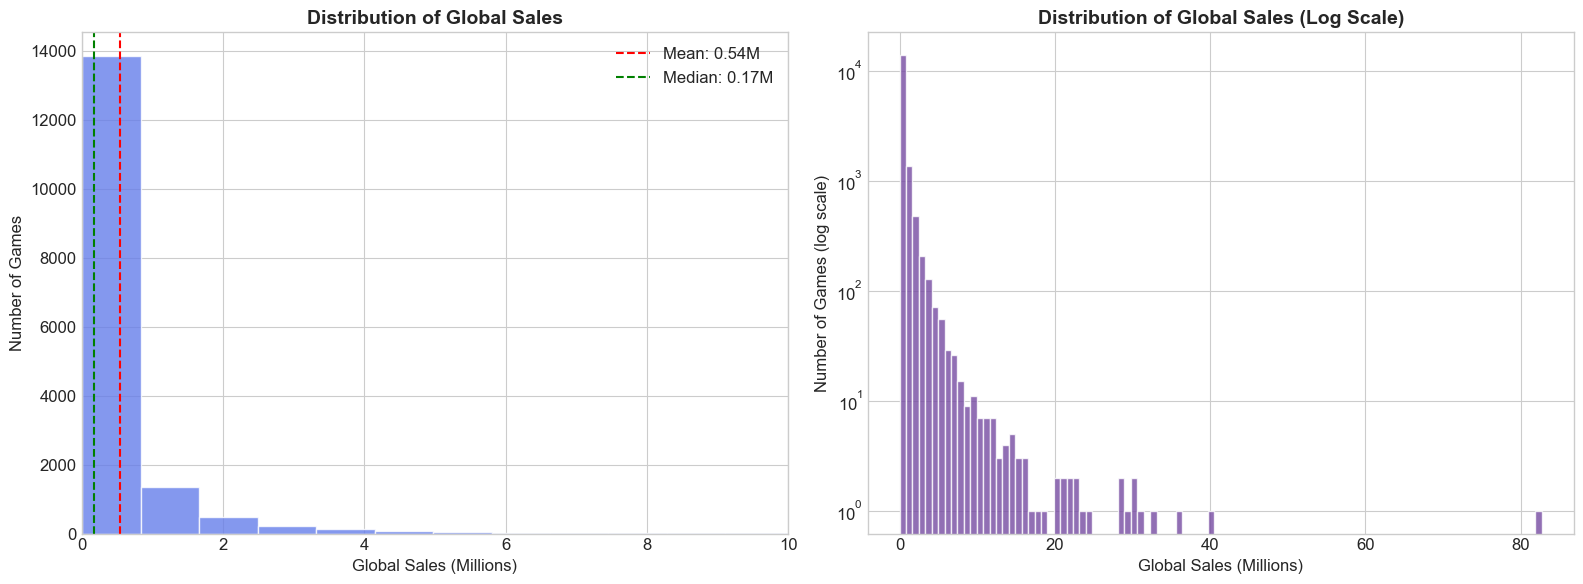

Mean global sales: 0.541M
Median global sales: 0.170M
Std deviation: 1.567M
Skewness: 17.30 (highly right-skewed)


In [ ]:
# Q1: Distribution of Global Sales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['Global_Sales'], bins=100, color='#667eea', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Global Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Global Sales (Millions)')
axes[0].set_ylabel('Number of Games')
axes[0].set_xlim(0, 10)
axes[0].axvline(df['Global_Sales'].mean(), color='red', linestyle='--', label=f'Mean: {df["Global_Sales"].mean():.2f}M')
axes[0].axvline(df['Global_Sales'].median(), color='green', linestyle='--', label=f'Median: {df["Global_Sales"].median():.2f}M')
axes[0].legend()

# Log-scale histogram
axes[1].hist(df['Global_Sales'], bins=100, color='#764ba2', edgecolor='white', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Distribution of Global Sales (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Global Sales (Millions)')
axes[1].set_ylabel('Number of Games (log scale)')

plt.tight_layout()
plt.show()

print(f"Mean global sales: {df['Global_Sales'].mean():.3f}M")
print(f"Median global sales: {df['Global_Sales'].median():.3f}M")
print(f"Std deviation: {df['Global_Sales'].std():.3f}M")
print(f"Skewness: {df['Global_Sales'].skew():.2f} (highly right-skewed)")

**Insight**: The distribution of global sales is **heavily right-skewed**. Most games sell less than 1 million copies, while a few blockbuster titles sell tens of millions. The mean (0.54M) is much higher than the median (0.17M), confirming the skew. This is typical in entertainment industry data — a small number of products generate most of the revenue.

## Question 2: Which game genre has the most titles in the dataset?

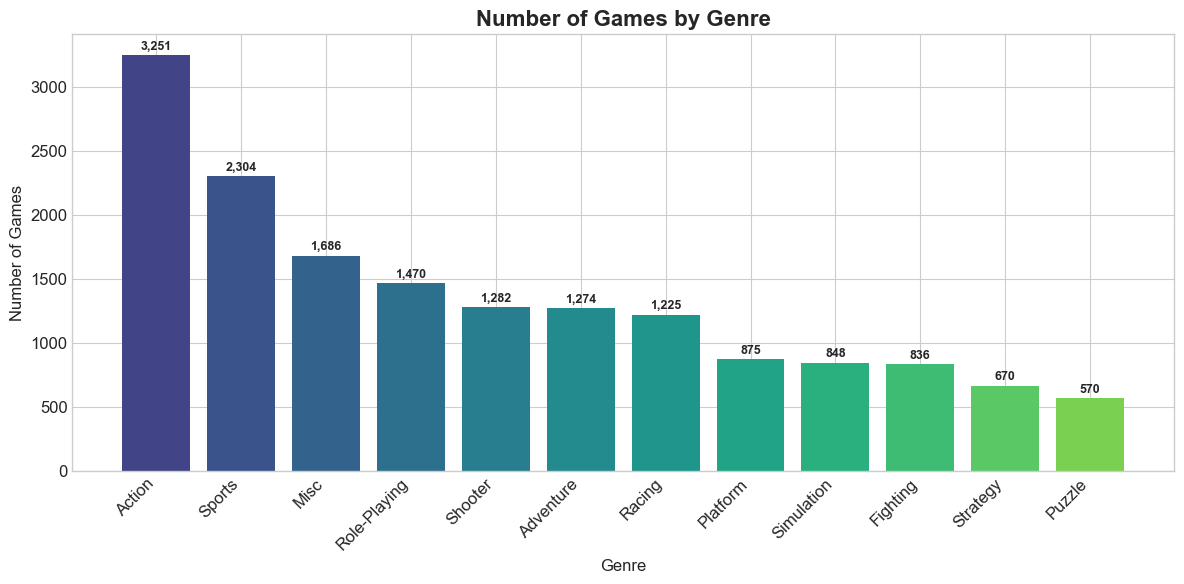

Most common genre: Action (3,251 games)
Least common genre: Puzzle (570 games)


In [ ]:
# Q2: Genre counts
genre_counts = df['Genre'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(genre_counts.index, genre_counts.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(genre_counts))))
plt.title('Number of Games by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, val in zip(bars, genre_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Most common genre: {genre_counts.index[0]} ({genre_counts.values[0]:,} games)")
print(f"Least common genre: {genre_counts.index[-1]} ({genre_counts.values[-1]:,} games)")

**Insight**: **Action** games dominate the market with the most titles. This makes sense because action games have broad appeal and relatively easier development cycles. **Puzzle** and **Strategy** games have fewer titles, possibly because they target a more niche audience.

## Question 3: What are the top 10 best-selling video games of all time?

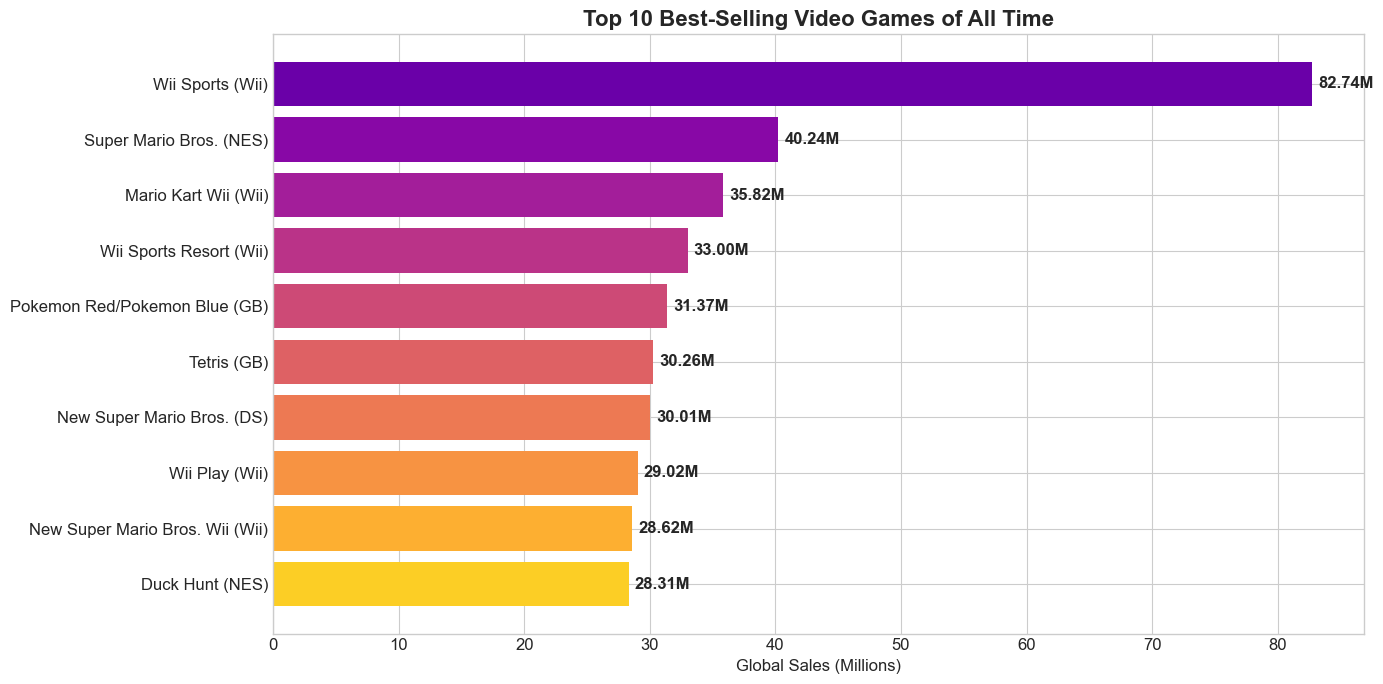

Top 10 Best-Selling Games:
  1. Wii Sports (Wii) — 82.74M
  2. Super Mario Bros. (NES) — 40.24M
  3. Mario Kart Wii (Wii) — 35.82M
  4. Wii Sports Resort (Wii) — 33.00M
  5. Pokemon Red/Pokemon Blue (GB) — 31.37M
  6. Tetris (GB) — 30.26M
  7. New Super Mario Bros. (DS) — 30.01M
  8. Wii Play (Wii) — 29.02M
  9. New Super Mario Bros. Wii (Wii) — 28.62M
  10. Duck Hunt (NES) — 28.31M


In [ ]:
# Q3: Top 10 best-selling games
top10 = df.nlargest(10, 'Global_Sales')[['Name', 'Platform', 'Year', 'Global_Sales']]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top10['Name'] + ' (' + top10['Platform'] + ')', top10['Global_Sales'],
               color=plt.cm.plasma(np.linspace(0.2, 0.9, 10)))
ax.set_xlabel('Global Sales (Millions)', fontsize=12)
ax.set_title('Top 10 Best-Selling Video Games of All Time', fontsize=16, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top10['Global_Sales']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{val:.2f}M', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Top 10 Best-Selling Games:")
for i, row in top10.iterrows():
    print(f"  {top10.index.get_loc(i)+1}. {row['Name']} ({row['Platform']}) — {row['Global_Sales']:.2f}M")

**Insight**: **Wii Sports** is the best-selling game of all time, largely because it was bundled with the Wii console. Nintendo dominates the top 10 list with several first-party titles. The top games span multiple decades and platforms, showing that blockbuster hits are not limited to one era.

## Question 4: How have global video game sales changed over the years?

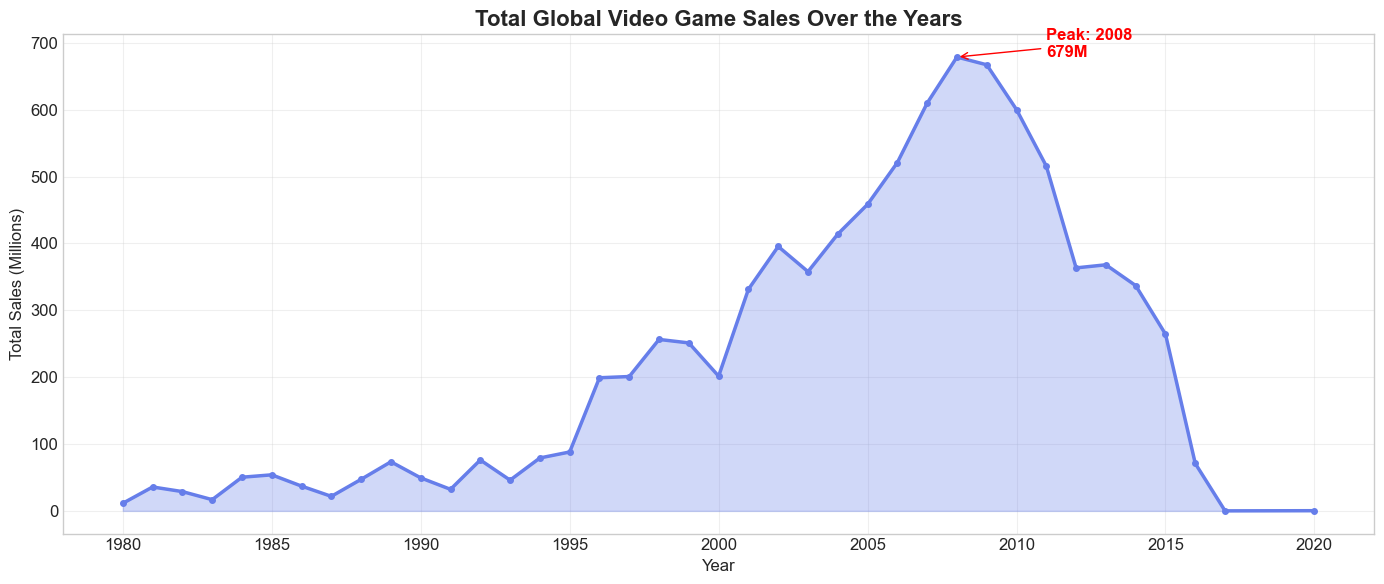

Peak year: 2008 with 678.9M in total sales
First year: 1980
Last year: 2020


In [ ]:
# Q4: Sales trends over years
yearly_sales = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(14, 6))
plt.fill_between(yearly_sales.index, yearly_sales.values, alpha=0.3, color='#667eea')
plt.plot(yearly_sales.index, yearly_sales.values, color='#667eea', linewidth=2.5, marker='o', markersize=4)

# Highlight peak year
peak_year = yearly_sales.idxmax()
peak_sales = yearly_sales.max()
plt.annotate(f'Peak: {int(peak_year)}\n{peak_sales:.0f}M',
             xy=(peak_year, peak_sales), xytext=(peak_year+3, peak_sales),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red', fontweight='bold')

plt.title('Total Global Video Game Sales Over the Years', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales (Millions)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak year: {int(peak_year)} with {peak_sales:.1f}M in total sales")
print(f"First year: {int(yearly_sales.index.min())}")
print(f"Last year: {int(yearly_sales.index.max())}")

**Insight**: The gaming industry experienced massive growth from 2000 to 2008, peaking around **2008-2009**. This was driven by the PS2/Wii/Xbox 360 era. After the peak, there was a decline, possibly due to the rise of mobile gaming and digital distribution changing how games are tracked.

## Question 5: Which gaming platform has the highest total global sales?

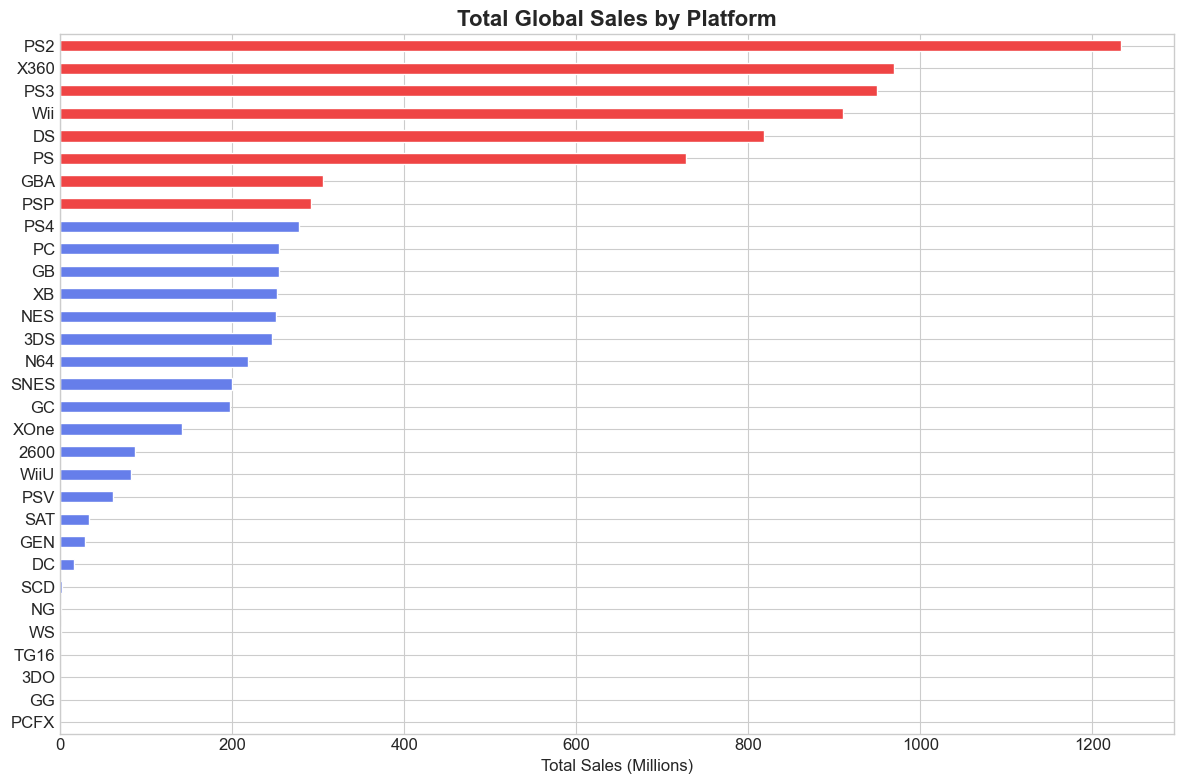

Top 3 Platforms by Total Sales:
   PS2: 1233.5M
   X360: 969.6M
   PS3: 949.4M


In [ ]:
# Q5: Platform sales ranking
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = ['#667eea' if v < platform_sales.quantile(0.75) else '#ef4444' for v in platform_sales.values]
platform_sales.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Total Global Sales by Platform', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales (Millions)')
plt.ylabel('')

plt.tight_layout()
plt.show()

top3 = platform_sales.nlargest(3)
print("Top 3 Platforms by Total Sales:")
for plat, sales in top3.items():
    print(f"   {plat}: {sales:.1f}M")

**Insight**: **PS2** leads all platforms in total global sales, followed by Xbox 360 and PS3. The top platforms represent the sixth and seventh console generations. Newer platforms like PS4 show strong sales but have not yet surpassed the PS2's lifetime total in this dataset.

## Question 6: What is the market share of each sales region?

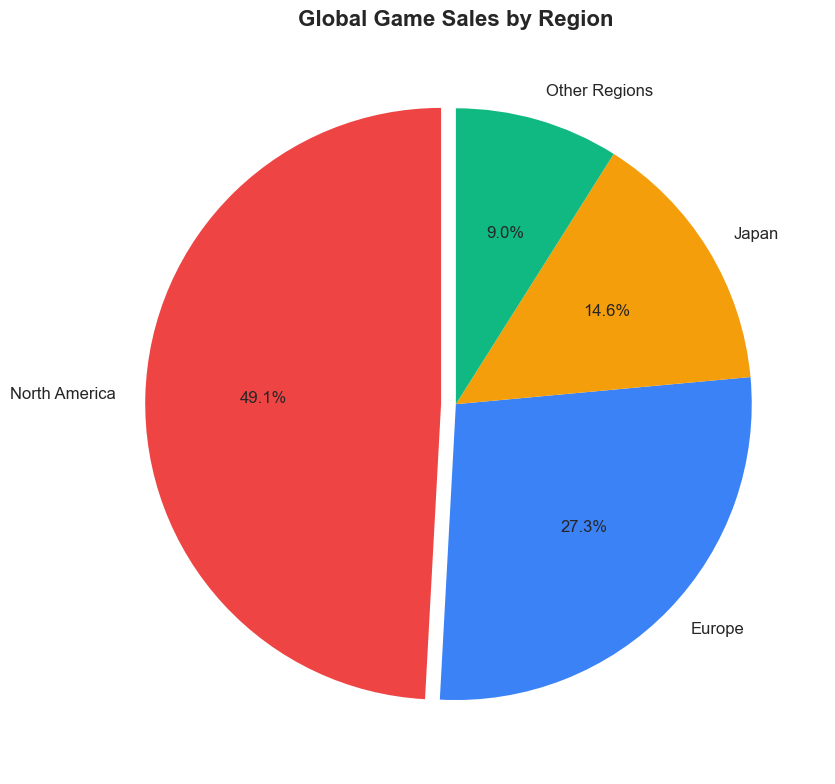

  North America: 4327.7M (49.1%)
  Europe: 2406.7M (27.3%)
  Japan: 1284.3M (14.6%)
  Other Regions: 788.9M (9.0%)


In [ ]:
# Q6: Regional market share
regions = {
    'North America': df['NA_Sales'].sum(),
    'Europe': df['EU_Sales'].sum(),
    'Japan': df['JP_Sales'].sum(),
    'Other Regions': df['Other_Sales'].sum()
}

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#ef4444', '#3b82f6', '#f59e0b', '#10b981']
wedges, texts, autotexts = ax.pie(
    regions.values(), labels=regions.keys(), autopct='%1.1f%%',
    colors=colors, startangle=90, explode=[0.05, 0, 0, 0],
    textprops={'fontsize': 12}
)
ax.set_title('Global Game Sales by Region', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

for region, sales in regions.items():
    pct = sales / sum(regions.values()) * 100
    print(f"  {region}: {sales:.1f}M ({pct:.1f}%)")

**Insight**: **North America** is the largest market, contributing almost **50%** of all global video game sales. Europe is the second-largest market at around **27%**. Japan, despite being a major game producer, accounts for a smaller share. This highlights the dominance of Western markets in video game consumption.

## Question 7: Which publishers have released the most game titles?

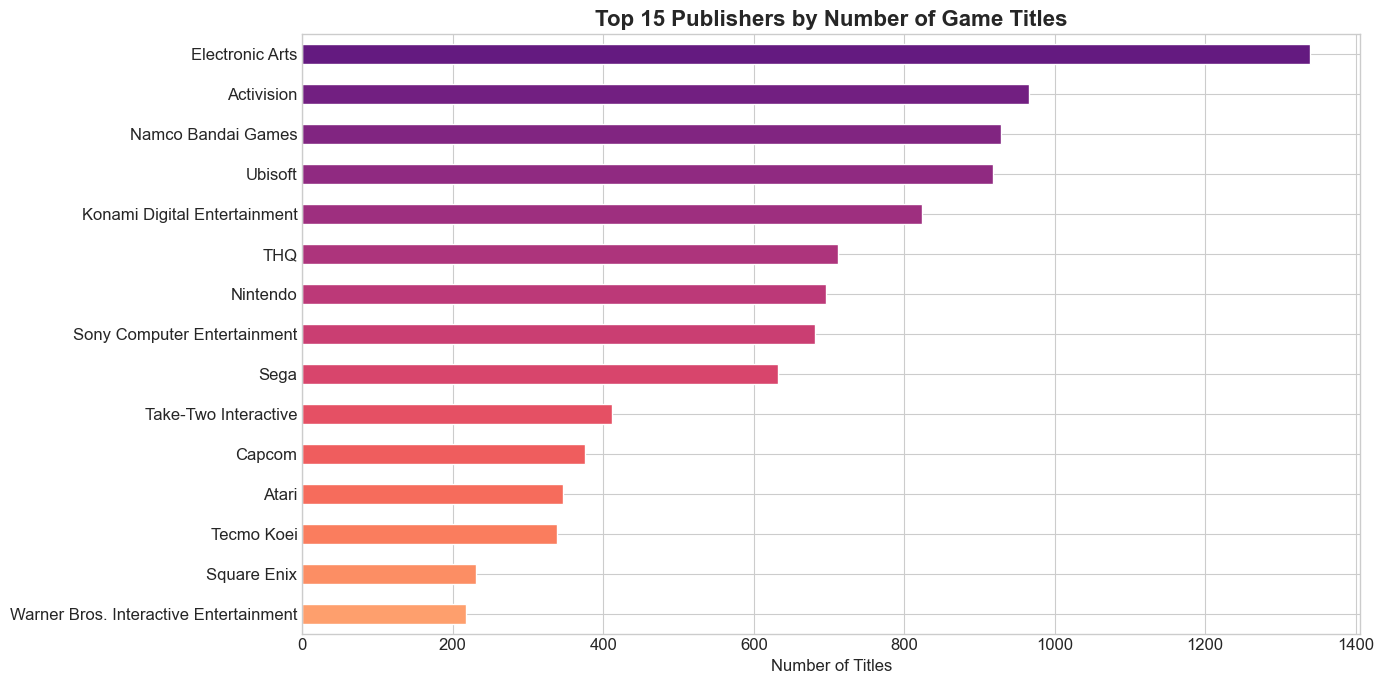

Total unique publishers: 576
Top publisher: Electronic Arts with 1,339 titles


In [ ]:
# Q7: Top publishers by title count
pub_counts = df['Publisher'].value_counts().head(15)

plt.figure(figsize=(14, 7))
pub_counts.plot(kind='barh', color=plt.cm.magma(np.linspace(0.3, 0.8, 15)), edgecolor='white')
plt.title('Top 15 Publishers by Number of Game Titles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Total unique publishers: {df['Publisher'].nunique()}")
print(f"Top publisher: {pub_counts.index[0]} with {pub_counts.values[0]:,} titles")

**Insight**: **Electronic Arts (EA)** leads in the number of game titles published, followed by other major publishers like Activision and Ubisoft. Having many titles does not always mean having the highest total sales, as quality and franchise strength matter more than quantity.

## Question 8: How do average sales differ across game genres?

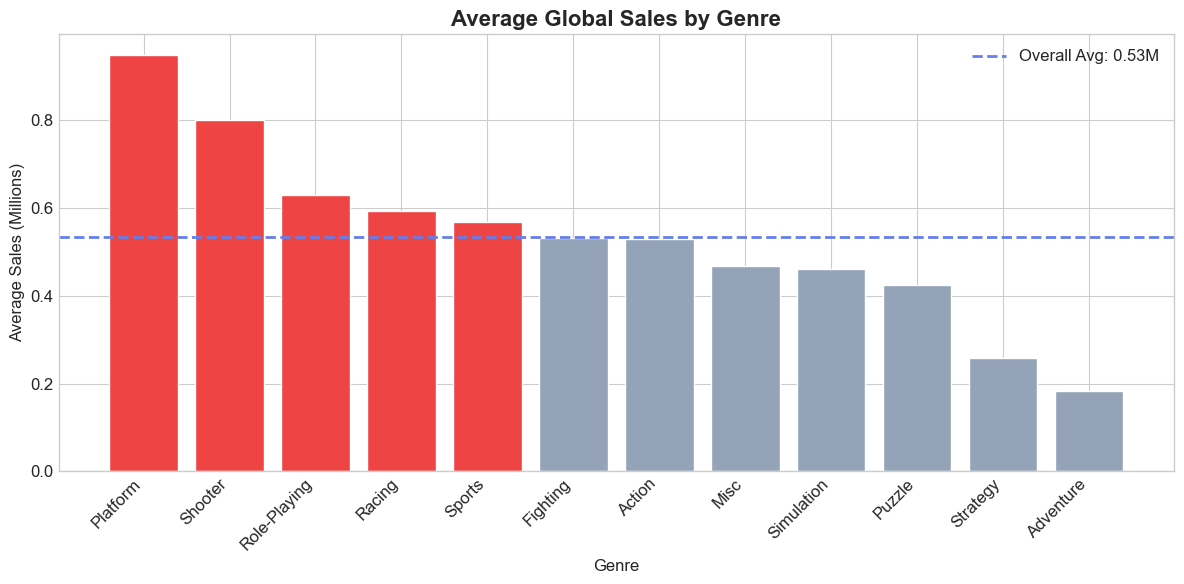

  Top Platform: 0.948M
  Top Shooter: 0.800M
  Top Role-Playing: 0.628M
  Top Racing: 0.593M
  Top Sports: 0.568M
     Fighting: 0.531M
     Action: 0.530M
     Misc: 0.468M
     Simulation: 0.460M
     Puzzle: 0.425M
     Strategy: 0.259M
     Adventure: 0.184M


In [ ]:
# Q8: Average sales by genre
genre_avg = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(genre_avg.index, genre_avg.values, 
               color=['#ef4444' if v > genre_avg.mean() else '#94a3b8' for v in genre_avg.values],
               edgecolor='white')
plt.axhline(y=genre_avg.mean(), color='#667eea', linestyle='--', linewidth=2, label=f'Overall Avg: {genre_avg.mean():.2f}M')
plt.title('Average Global Sales by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Average Sales (Millions)')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

for genre, avg in genre_avg.items():
    marker = 'Top' if avg > genre_avg.mean() else '  '
    print(f"  {marker} {genre}: {avg:.3f}M")

**Insight**: Genres like **Platform** and **Shooter** have the highest average sales per game, meaning individual titles in these genres tend to sell better. Even though **Action** has the most titles, its average sales are not the highest, suggesting a very competitive market with many lower-selling titles.

## Question 9: How do sales trends differ across regions over time?

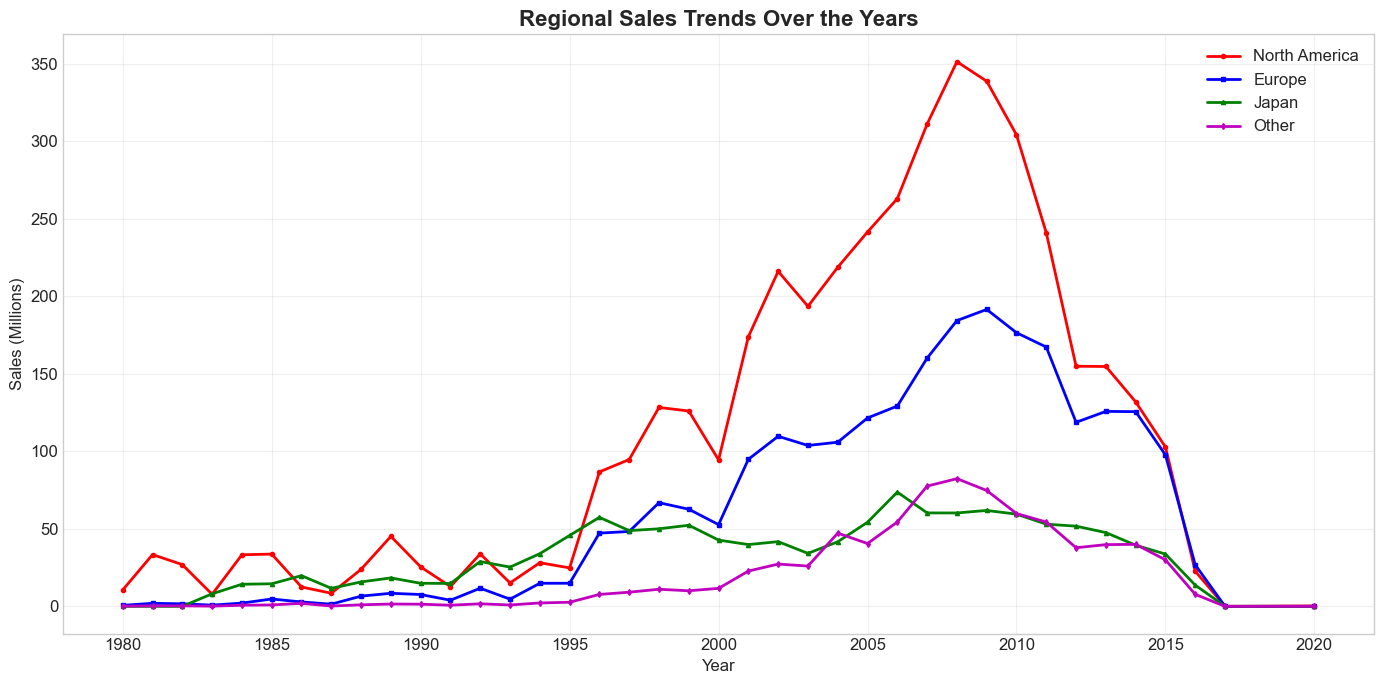

Regional sales peak years:
  NA: 2008 (351.4M)
  EU: 2009 (191.6M)
  Japan: 2006 (73.7M)
  Other: 2008 (82.4M)


In [ ]:
# Q9: Regional sales trends over time
yearly_region = df.groupby('Year').agg({
    'NA_Sales': 'sum', 'EU_Sales': 'sum', 'JP_Sales': 'sum', 'Other_Sales': 'sum'
})

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(yearly_region.index, yearly_region['NA_Sales'], 'r-o', label='North America', linewidth=2, markersize=3)
ax.plot(yearly_region.index, yearly_region['EU_Sales'], 'b-s', label='Europe', linewidth=2, markersize=3)
ax.plot(yearly_region.index, yearly_region['JP_Sales'], 'g-^', label='Japan', linewidth=2, markersize=3)
ax.plot(yearly_region.index, yearly_region['Other_Sales'], 'm-d', label='Other', linewidth=2, markersize=3)

ax.set_title('Regional Sales Trends Over the Years', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sales (Millions)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Regional sales peak years:")
for col, name in [('NA_Sales','NA'), ('EU_Sales','EU'), ('JP_Sales','Japan'), ('Other_Sales','Other')]:
    peak = yearly_region[col].idxmax()
    print(f"  {name}: {int(peak)} ({yearly_region[col].max():.1f}M)")

**Insight**: All regions follow a similar overall trend, peaking around **2008**. However, **Japan** had an earlier peak in the mid-1990s, reflecting the golden age of Japanese gaming (SNES, PS1). North America consistently leads in sales volume across all years.

## Question 10: Which are the top 5 game genres for each major platform?

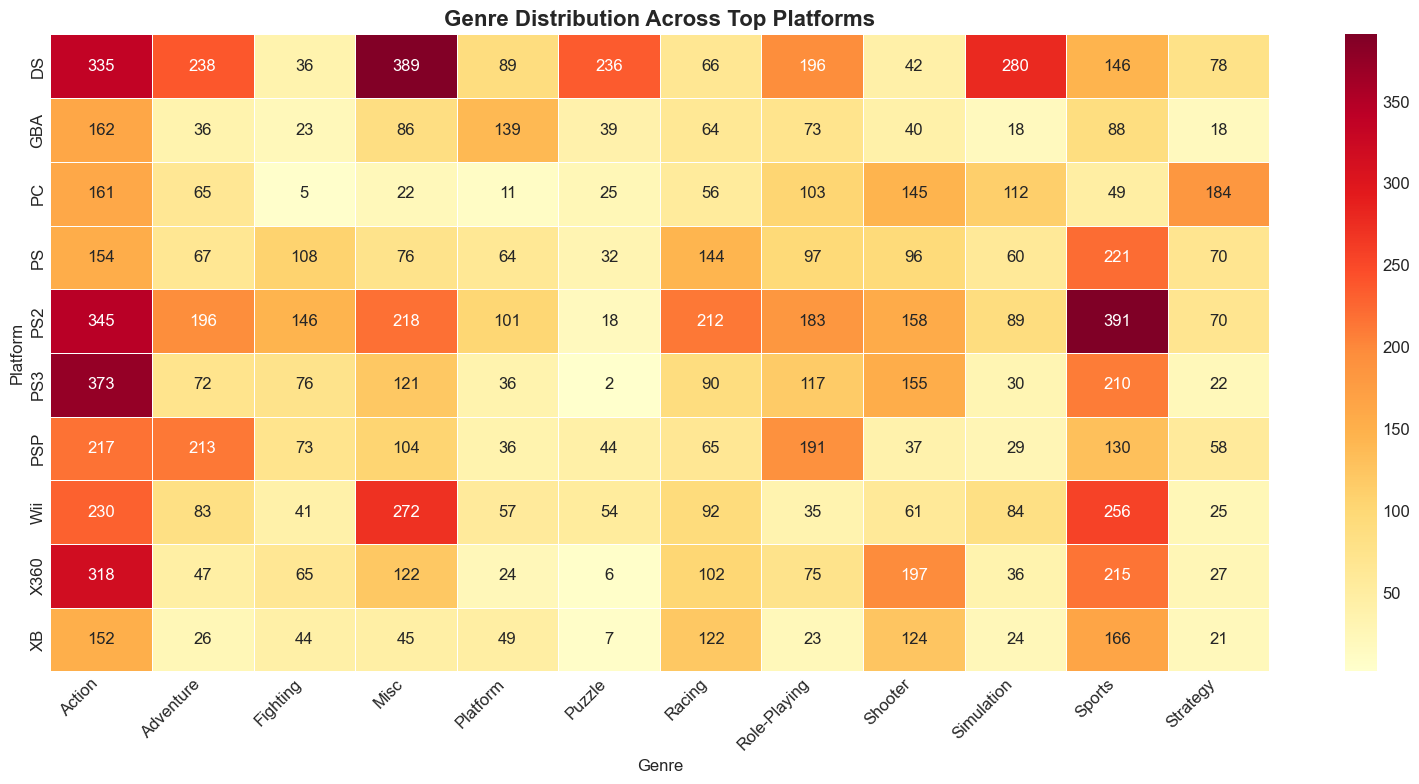

Top 3 genres per platform:
  DS: Misc, Action, Simulation
  PS2: Sports, Action, Misc
  PS3: Action, Sports, Shooter
  Wii: Misc, Sports, Action
  X360: Action, Sports, Shooter
  PSP: Action, Adventure, Role-Playing


In [ ]:
# Q10: Top genres by platform (heatmap)
top_platforms = df['Platform'].value_counts().head(10).index
sub = df[df['Platform'].isin(top_platforms)]

# Create a cross-tabulation
cross = pd.crosstab(sub['Platform'], sub['Genre'])

plt.figure(figsize=(16, 8))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Genre Distribution Across Top Platforms', fontsize=16, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Platform')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Show top 3 genres for each platform
print("Top 3 genres per platform:")
for plat in top_platforms[:6]:
    plat_data = df[df['Platform'] == plat]['Genre'].value_counts().head(3)
    print(f"  {plat}: {', '.join(plat_data.index.tolist())}")

**Insight**: Different platforms show different genre preferences. **DS and Wii** tend to have more **Misc** and **Sports** games, while **PS3 and X360** favor **Action** and **Shooter** games. This reflects each platform's target audience and hardware capabilities.

## Question 11: Is there a trend in the number of new games released per year?

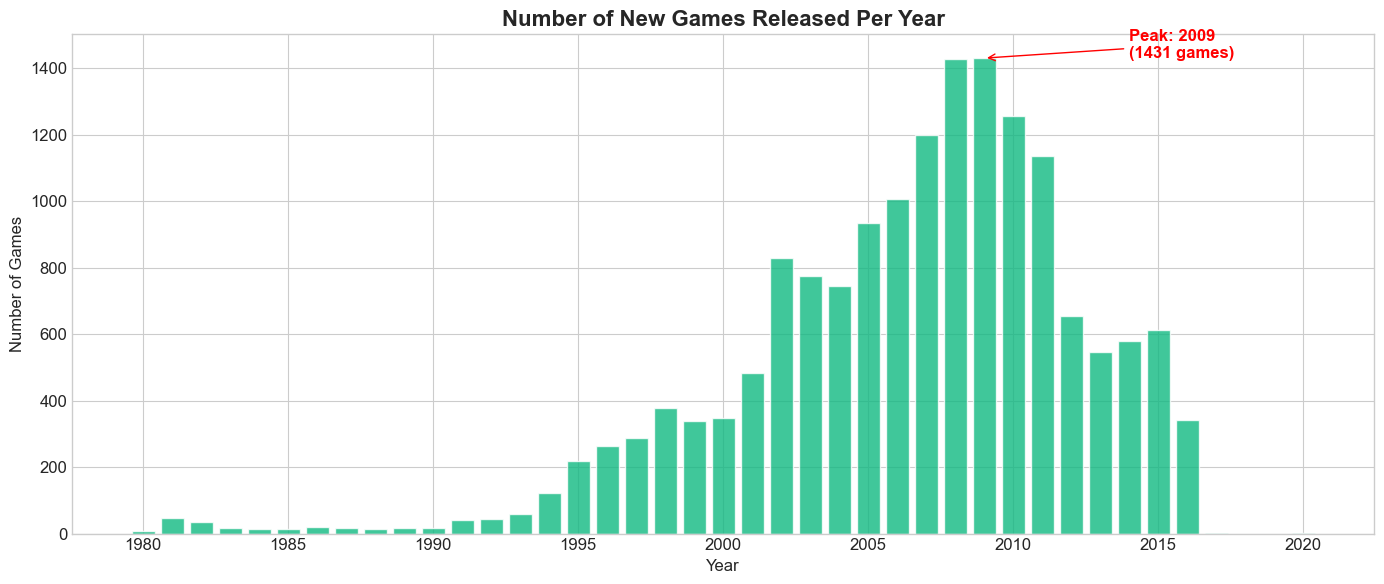

Peak year for releases: 2009 with 1431 games
Average games per year: 418


In [ ]:
# Q11: Games released per year
games_per_year = df.groupby('Year').size()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(games_per_year.index, games_per_year.values, color='#10b981', edgecolor='white', alpha=0.8)
ax.set_title('Number of New Games Released Per Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games')

# Add trend annotation
peak_yr = games_per_year.idxmax()
ax.annotate(f'Peak: {int(peak_yr)}\n({games_per_year.max()} games)',
            xy=(peak_yr, games_per_year.max()), xytext=(peak_yr+5, games_per_year.max()),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Peak year for releases: {int(peak_yr)} with {games_per_year.max()} games")
print(f"Average games per year: {games_per_year.mean():.0f}")

**Insight**: The number of game releases grew steadily from the 1980s, exploded in the mid-2000s, and peaked around **2008-2009**. After the peak, there was a sharp decline. This could be because fewer games are being released for physical retail, or the rise of mobile and indie games changed the market.

## Question 12: Which year had the highest total global sales and why?

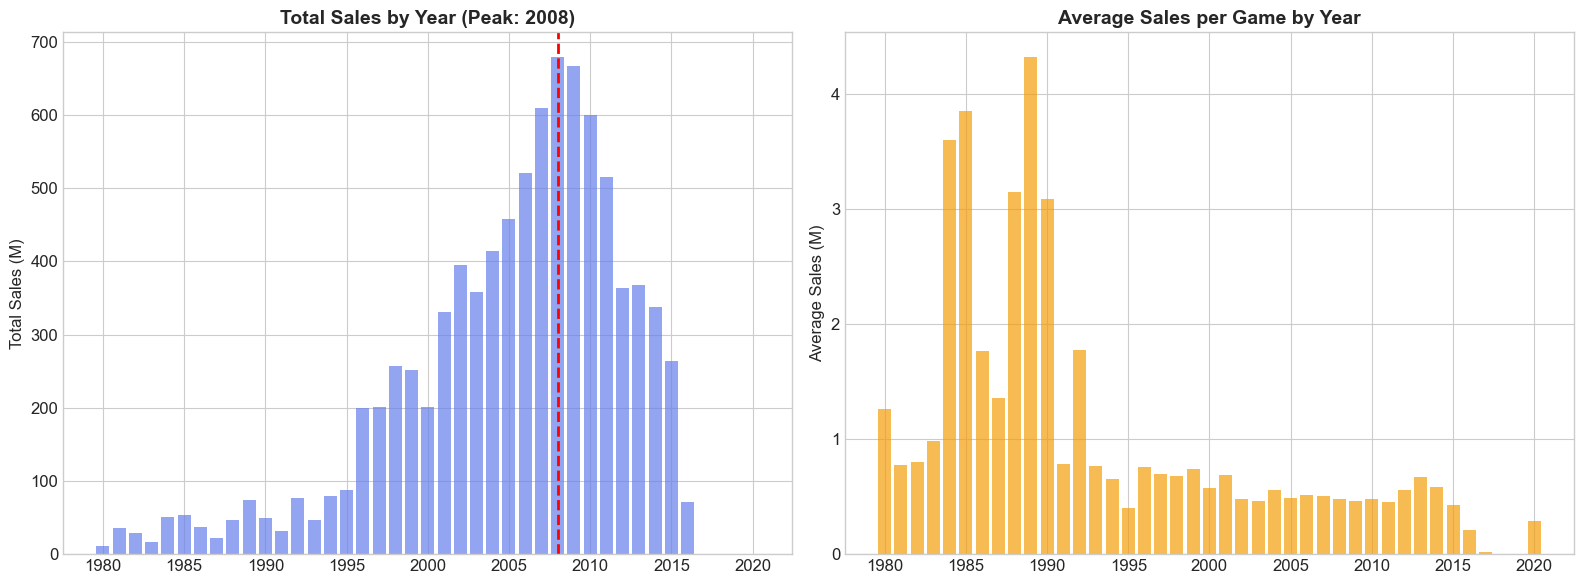

   Best Year: 2008
   Total Sales: 678.9M
   Games Released: 1428
   Average Sales per Game: 0.48M

 The peak was driven by a combination of many releases AND high average sales per game.


In [ ]:
# Q12: Best year analysis
yearly = df.groupby('Year').agg({'Global_Sales': ['sum', 'count', 'mean']}).reset_index()
yearly.columns = ['Year', 'Total_Sales', 'Game_Count', 'Avg_Sales']

best = yearly.loc[yearly['Total_Sales'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total sales by year
axes[0].bar(yearly['Year'], yearly['Total_Sales'], color='#667eea', alpha=0.7)
axes[0].axvline(x=best['Year'], color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'Total Sales by Year (Peak: {int(best["Year"])})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales (M)')

# Average sales by year
axes[1].bar(yearly['Year'], yearly['Avg_Sales'], color='#f59e0b', alpha=0.7)
axes[1].set_title('Average Sales per Game by Year', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Sales (M)')

plt.tight_layout()
plt.show()

print(f"   Best Year: {int(best['Year'])}")
print(f"   Total Sales: {best['Total_Sales']:.1f}M")
print(f"   Games Released: {int(best['Game_Count'])}")
print(f"   Average Sales per Game: {best['Avg_Sales']:.2f}M")
print(f"\n The peak was driven by a combination of many releases AND high average sales per game.")

**Insight**: The best year for total sales was around **2008**, driven by blockbuster titles on Wii, DS, Xbox 360, and PS3. Interestingly, the highest average sales per game occurred in the early 1990s, when fewer but more impactful games were released (like Super Mario and Sonic).

## Question 13: What is the average global sales per game by genre?

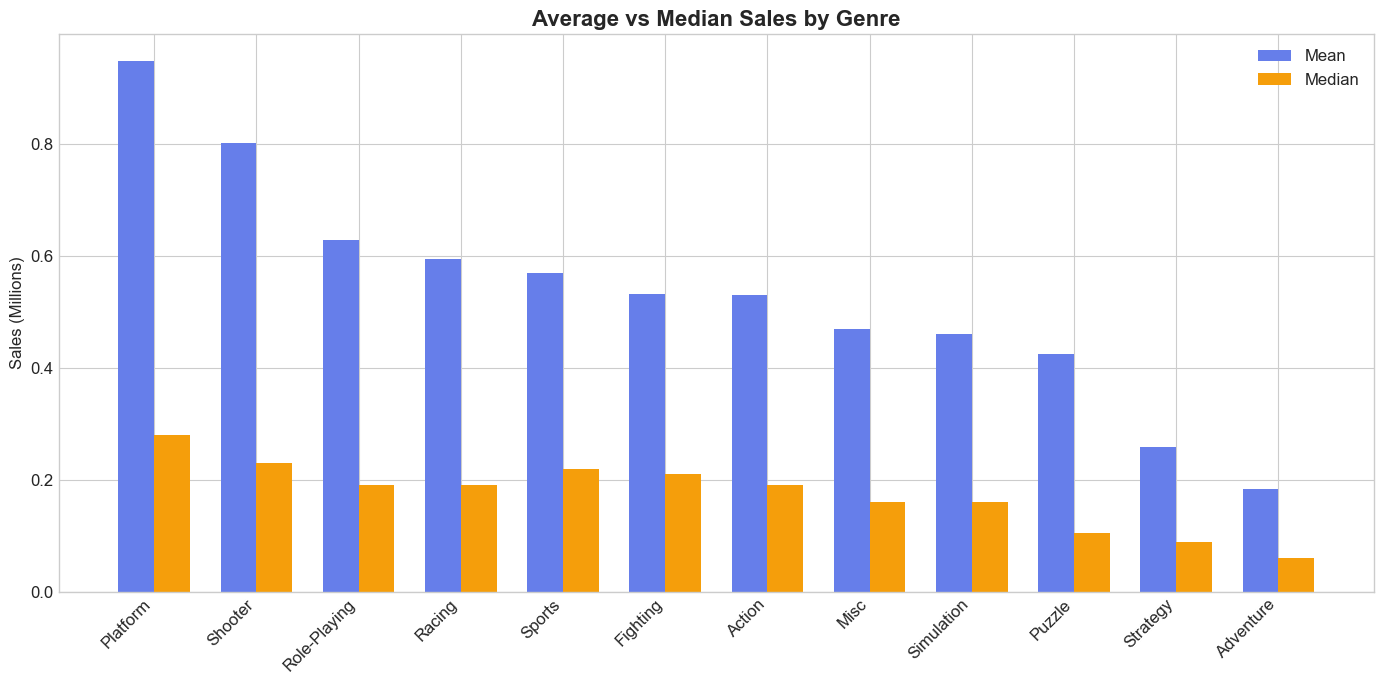

               mean  median    std
Genre                             
Platform      0.948   0.280  2.600
Shooter       0.800   0.230  1.834
Role-Playing  0.628   0.190  1.717
Racing        0.593   0.190  1.677
Sports        0.568   0.220  2.105
Fighting      0.531   0.210  0.958
Action        0.530   0.190  1.165
Misc          0.468   0.160  1.332
Simulation    0.460   0.160  1.207
Puzzle        0.425   0.105  1.578
Strategy      0.259   0.090  0.525
Adventure     0.184   0.060  0.511


In [ ]:
# Q13: Average and median sales by genre (comparison)
genre_stats = df.groupby('Genre')['Global_Sales'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(genre_stats))
width = 0.35

ax.bar([i - width/2 for i in x], genre_stats['mean'], width, label='Mean', color='#667eea')
ax.bar([i + width/2 for i in x], genre_stats['median'], width, label='Median', color='#f59e0b')

ax.set_xticks(x)
ax.set_xticklabels(genre_stats.index, rotation=45, ha='right')
ax.set_title('Average vs Median Sales by Genre', fontsize=16, fontweight='bold')
ax.set_ylabel('Sales (Millions)')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(genre_stats.round(3))

**Insight**: There is a big difference between mean and median sales for all genres, confirming the **heavy-tailed distribution**. A few blockbuster titles pull the mean much higher than the median. Platform and Shooter genres show the largest gap, meaning their top titles are extremely successful compared to average titles.

## Question 14: How has platform popularity changed over the decades?

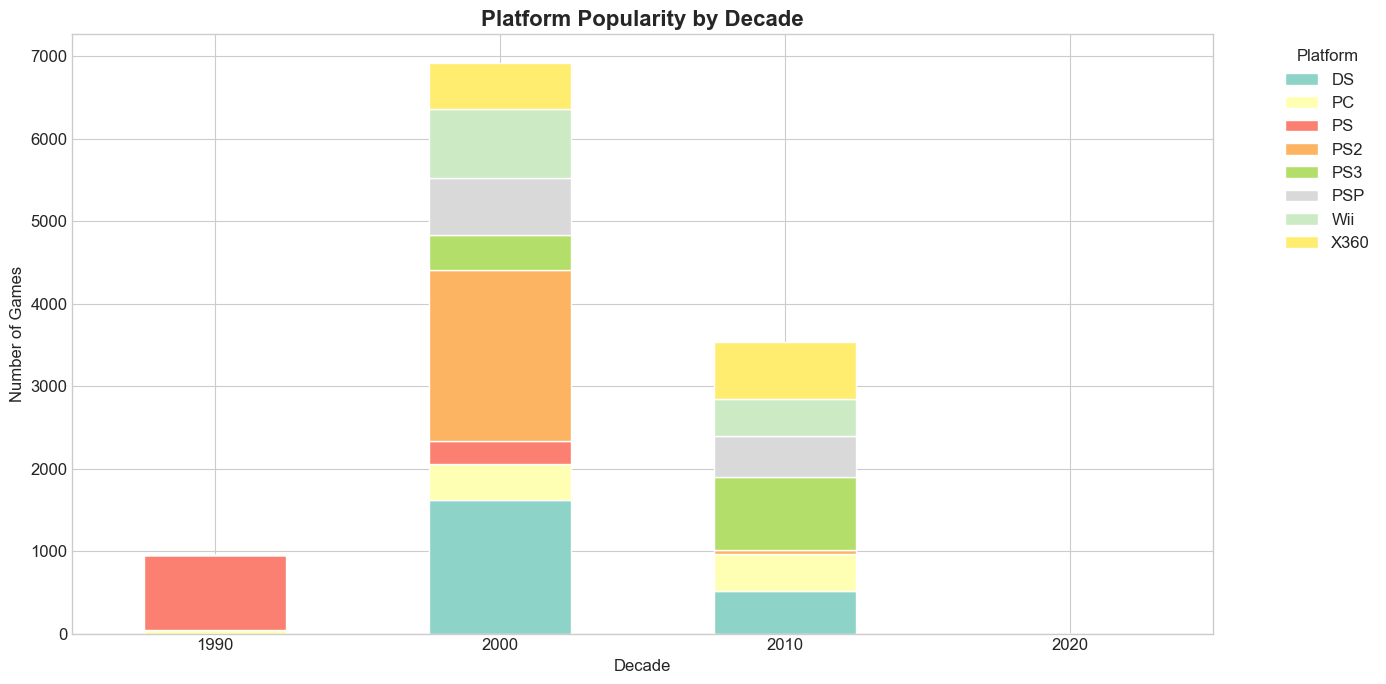

Dominant platform per decade:
  1990s: PS (916 games)
  2000s: PS2 (2082 games)
  2010s: PS3 (886 games)
  2020s: DS (1 games)


In [ ]:
# Q14: Platform popularity by decade
decades = df[df['Decade'] >= 1990]
top_plats = decades['Platform'].value_counts().head(8).index
sub = decades[decades['Platform'].isin(top_plats)]

plat_decade = pd.crosstab(sub['Decade'], sub['Platform'])

fig, ax = plt.subplots(figsize=(14, 7))
plat_decade.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', edgecolor='white')
ax.set_title('Platform Popularity by Decade', fontsize=16, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Games')
ax.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("Dominant platform per decade:")
for decade in plat_decade.index:
    top = plat_decade.loc[decade].idxmax()
    print(f"  {int(decade)}s: {top} ({int(plat_decade.loc[decade][top])} games)")

**Insight**: Each decade has a dominant platform. The **2000s** saw PS2 dominate, while the **2010s** were more competitive with PS3, X360, and PS4 sharing the market. The shift from one generation to the next is clearly visible in the data.

## Question 15: Which publishers dominate sales in each global region?

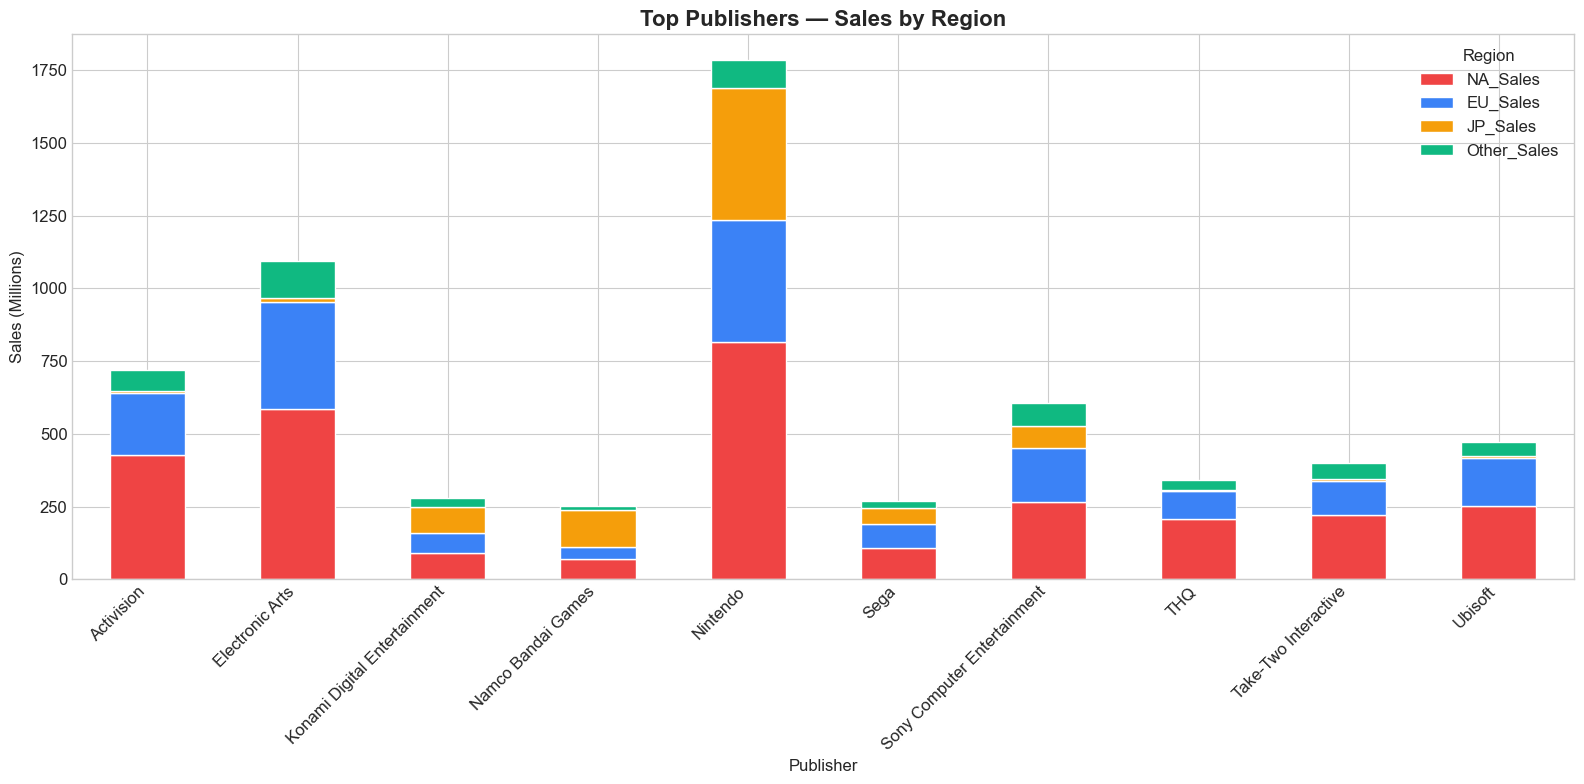

Top publisher per region:
  North America: Nintendo (815.8M)
  Europe: Nintendo (418.3M)
  Japan: Nintendo (455.0M)
  Other: Electronic Arts (127.6M)


In [ ]:
# Q15: Top publishers by region
top_pubs = df['Publisher'].value_counts().head(10).index
sub = df[df['Publisher'].isin(top_pubs)]

region_pub = sub.groupby('Publisher').agg({
    'NA_Sales': 'sum', 'EU_Sales': 'sum', 'JP_Sales': 'sum', 'Other_Sales': 'sum'
})

fig, ax = plt.subplots(figsize=(16, 8))
region_pub.plot(kind='bar', stacked=True, ax=ax, 
                color=['#ef4444', '#3b82f6', '#f59e0b', '#10b981'],
                edgecolor='white')
ax.set_title('Top Publishers — Sales by Region', fontsize=16, fontweight='bold')
ax.set_xlabel('Publisher')
ax.set_ylabel('Sales (Millions)')
ax.legend(title='Region')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Top publisher per region:")
for col, name in [('NA_Sales','North America'), ('EU_Sales','Europe'), 
                   ('JP_Sales','Japan'), ('Other_Sales','Other')]:
    top = region_pub[col].idxmax()
    print(f"  {name}: {top} ({region_pub[col].max():.1f}M)")

**Insight**: **Nintendo** tends to dominate across all regions, especially in Japan. However, regional differences exist: some publishers are strong in North America but weaker in Japan, and vice versa. This reflects cultural differences in gaming preferences and marketing strategies.

---
## 7️ Final Insights & Conclusions

---

### Key Findings

1. **Sales Distribution**: The video game market is extremely top-heavy. A small number of blockbuster titles generate most of the revenue, while the majority of games sell modestly.

2. **Genre Insights**: Action games are the most common, but Platform and Shooter games tend to have higher average sales per title.

3. **Platform Lifecycle**: Each console generation has a clear lifecycle of about 5-7 years. PS2 remains the best-selling platform of all time.

4. **Regional Differences**: North America is the largest market (~50%), followed by Europe (~27%). Japan, despite being home to major publishers, is a smaller market.

5. **Industry Peak**: The gaming industry (in terms of retail sales) peaked around 2008-2009, driven by the Wii, DS, PS2, and Xbox 360 era.

6. **Publisher Dynamics**: Nintendo dominates in total sales per title, while EA leads in volume of releases.

7. **Time Trends**: The number of game releases has declined since 2009, possibly due to the shift toward digital distribution and mobile gaming.

### Recommendations

- Game publishers should focus on **Action, Shooter, and Platform** genres for maximum sales potential
- **North America** should remain the primary target market
- Understanding platform lifecycle timing is crucial for release planning
- Quality matters more than quantity — blockbuster titles drive the industry

---

---
## 8️ References

---

1. Kaggle Video Game Sales Dataset: https://www.kaggle.com/datasets/gregorut/videogame-sales
2. Pandas Documentation: https://pandas.pydata.org/docs/
3. Matplotlib Documentation: https://matplotlib.org/
4. Seaborn Documentation: https://seaborn.pydata.org/
5. Plotly Python Documentation: https://plotly.com/python/
6. Missingno Library: https://github.com/ResidentMario/missingno
7. Wikipedia — Video Game Industry: https://en.wikipedia.org/wiki/Video_game_industry

---

